# 08 Transformer Feature Replacement Experiment

This notebook takes the next focused step for the transformer model.

We now **fix the architecture near the best regularized setting** and test whether a cleaner feature set can help more than another round of scaling the model up.

The main comparison is:

1. `regularized_small_fast_current`: the current regularized baseline,
2. `regularized_small_replacement`: the same model with weaker short-horizon raw-return features replaced by stronger regime / range features,
3. `regularized_shorter_replacement`: the same replacement feature set with a shorter lookback to see whether it also reduces lag.

The train / validation / test years stay unchanged so the results remain directly comparable to earlier notebooks.

In [1]:
from pathlib import Path
import copy
import itertools
import math
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

os.environ.setdefault('KMP_DUPLICATE_LIB_OK', 'TRUE')

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

PROJECT_DIR = Path('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project')
DATA_DIR = PROJECT_DIR / 'data'
FIGURE_DIR = PROJECT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DF_PATH = DATA_DIR / 'model_df_2016_2025.csv.gz'

try:
    mpl_dir = PROJECT_DIR / '.matplotlib'
    mpl_dir.mkdir(exist_ok=True)
except PermissionError:
    mpl_dir = Path('/tmp/erdos_vol_pred_runtime/.matplotlib')
    mpl_dir.mkdir(parents=True, exist_ok=True)

os.environ['MPLCONFIGDIR'] = str(mpl_dir)

assert MODEL_DF_PATH.exists(), f'Run 01_data_download_and_features.ipynb first: {MODEL_DF_PATH}'

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

DEVICE

device(type='mps')

## Feature replacement design

The `fast_current` set is the strongest starting point from the last tuning notebook.

The new `replacement_hybrid` set keeps that skeleton, but explicitly **replaces several weak short-horizon raw-return style features** with stronger medium-horizon regime and proxy features that looked more useful in the last review.

In [2]:
model_df = pd.read_csv(MODEL_DF_PATH, parse_dates=['Date']).sort_values(['Ticker', 'Date']).reset_index(drop=True)

base_features = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'realized_vol_5d', 'realized_vol_21d', 'realized_vol_63d',
    'hist_vol_5d', 'hist_vol_21d',
    'volume_zscore_21d', 'abs_return_mean_5d', 'parkinson_vol_5d',
    'mkt_SPY_proxy_return', 'mkt_SPY_proxy_hist_vol_5d',
    'mkt_QQQ_proxy_return', 'mkt_QQQ_proxy_hist_vol_21d',
    'mkt_IWM_proxy_return',
    'macro_^VIX_proxy_level_zscore_21d', 'macro_^TNX_proxy_return',
    'macro_HYG_proxy_return', 'macro_LQD_proxy_return',
]

fast_extra_features = [
    'volume_zscore_5d', 'return_mean_5d', 'realized_vol_10d', 'parkinson_vol_21d',
    'mkt_SPY_proxy_range', 'mkt_QQQ_proxy_range', 'mkt_IWM_proxy_range',
    'macro_^VIX_proxy_return', 'macro_^VIX_proxy_hist_vol_5d', 'macro_^VIX_proxy_range',
]

features_to_remove = [
    'abs_return', 'squared_return', 'realized_vol_5d',
    'hist_vol_5d', 'abs_return_mean_5d', 'return_mean_5d',
]

features_to_add = [
    'abs_return_mean_21d', 'hist_vol_63d', 'macro_^TNX_proxy_range',
    'macro_^VIX_proxy_level_zscore_63d', 'mkt_IWM_proxy_level_zscore_63d',
    'mkt_QQQ_proxy_level_zscore_21d',
]

fast_current = base_features + fast_extra_features
replacement_hybrid = [feature for feature in fast_current if feature not in features_to_remove] + features_to_add

feature_sets = {
    'fast_current': fast_current,
    'replacement_hybrid': replacement_hybrid,
}

selected_tickers = ['AAPL', 'MSFT', 'NVDA', 'JPM', 'XOM']
target_columns = ['Date', 'Ticker', 'fvol_5d', 'log_fvol_5d']

feature_summary_df = pd.DataFrame({
    'feature_set': list(feature_sets.keys()),
    'feature_count': [len(v) for v in feature_sets.values()],
})
replacement_actions_df = pd.DataFrame({
    'removed': pd.Series(features_to_remove),
    'added': pd.Series(features_to_add),
})

display(feature_summary_df)
replacement_actions_df

,feature_set,feature_count
0,fast_current,31
1,replacement_hybrid,31


,removed,added
0,abs_return,abs_return_mean_21d
1,squared_return,hist_vol_63d
2,realized_vol_5d,macro_^TNX_proxy_range
3,hist_vol_5d,macro_^VIX_proxy_level_zscore_63d
4,abs_return_mean_5d,mkt_IWM_proxy_level_zscore_63d
5,return_mean_5d,mkt_QQQ_proxy_level_zscore_21d


## XGBoost-guided feature review

Before training more transformers, we fit the same strong XGBoost setup on the training period and use its feature importances as a diagnostic. This is not treated as a final decision rule, but it gives a useful signal about which inputs look strongest in a nonlinear tabular model.

In [3]:
xgb_train_df = model_df[model_df['Date'].dt.year < 2025].copy()
stock_feature_columns = [
    'abs_return', 'squared_return', 'high_low_log_range', 'log_volume',
    'hist_vol_5d', 'hist_vol_10d', 'hist_vol_21d', 'hist_vol_63d',
    'realized_vol_5d', 'realized_vol_10d', 'realized_vol_21d', 'realized_vol_63d',
    'volume_zscore_5d', 'volume_zscore_10d', 'volume_zscore_21d', 'volume_zscore_63d',
    'return_mean_5d', 'return_mean_21d',
    'abs_return_mean_5d', 'abs_return_mean_21d',
    'parkinson_vol_5d', 'parkinson_vol_21d',
]
dynamic_proxy_columns = [
    col for col in model_df.columns
    if (col.startswith('mkt_') or col.startswith('macro_')) and not col.endswith('_proxy_level')
]
xgb_num_features = stock_feature_columns + dynamic_proxy_columns
xgb_preprocess = ColumnTransformer([
    ('num', 'passthrough', xgb_num_features),
    ('ticker', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), ['Ticker']),
])
xgb_model = XGBRegressor(
    objective='reg:squarederror',
    tree_method='hist',
    random_state=42,
    n_jobs=4,
    verbosity=0,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=5,
    reg_lambda=5,
)
xgb_pipe = Pipeline([('preprocess', xgb_preprocess), ('model', xgb_model)])
xgb_pipe.fit(xgb_train_df[['Ticker'] + xgb_num_features], xgb_train_df['log_fvol_5d'])
feature_names = list(xgb_pipe.named_steps['preprocess'].get_feature_names_out())
importances = xgb_pipe.named_steps['model'].feature_importances_
xgb_importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
xgb_importance_df = xgb_importance_df[xgb_importance_df['feature'].str.startswith('num__')].copy()
xgb_importance_df['feature'] = xgb_importance_df['feature'].str.replace('^num__', '', regex=True)
xgb_importance_df = xgb_importance_df.sort_values('importance', ascending=False).reset_index(drop=True)
xgb_importance_df.head(25)

,feature,importance
0,parkinson_vol_21d,0.195037
1,parkinson_vol_5d,0.155878
2,high_low_log_range,0.065815
3,abs_return_mean_21d,0.050016
4,realized_vol_63d,0.038214
5,hist_vol_63d,0.029113
6,mkt_SPY_proxy_hist_vol_5d,0.026696
7,macro_^TNX_proxy_range,0.024745
8,realized_vol_10d,0.020215
9,macro_^VIX_proxy_level_zscore_63d,0.019359


## Transformer experiment grid

The architecture is now intentionally conservative. The real question here is whether **feature replacement** helps more than another round of model scaling.

We keep the best regularized setup as the default and only vary the feature set and, once, the lookback.

In [4]:
experiments = [
    {
        'name': 'regularized_small_fast_current',
        'feature_set': 'fast_current',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
    {
        'name': 'regularized_small_replacement',
        'feature_set': 'replacement_hybrid',
        'lookback': 90,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
    {
        'name': 'regularized_shorter_replacement',
        'feature_set': 'replacement_hybrid',
        'lookback': 60,
        'd_model': 64,
        'dim_feedforward': 128,
        'dropout': 0.3,
        'learning_rate': 3e-4,
        'weight_decay': 1e-3,
        'batch_size': 512,
        'epochs': 30,
        'patience': 6,
    },
]
train_end_year = 2023
validation_year = 2024
test_year = 2025
pd.DataFrame(experiments)

,name,feature_set,lookback,d_model,dim_feedforward,dropout,learning_rate,weight_decay,batch_size,epochs,patience
0,regularized_small_fast_current,fast_current,90,64,128,0.3,0.0003,0.001,512,30,6
1,regularized_small_replacement,replacement_hybrid,90,64,128,0.3,0.0003,0.001,512,30,6
2,regularized_shorter_replacement,replacement_hybrid,60,64,128,0.3,0.0003,0.001,512,30,6


In [5]:
class RollingSequenceDataset(Dataset):
    def __init__(self, grouped_data, ticker_to_idx, lookback, allowed_years):
        self.grouped_data = grouped_data
        self.ticker_to_idx = ticker_to_idx
        self.lookback = lookback
        self.allowed_years = set(allowed_years)
        self.samples = []
        for ticker, panel in grouped_data.items():
            for end_idx in range(lookback - 1, len(panel['dates'])):
                if panel['dates'][end_idx].year in self.allowed_years:
                    self.samples.append((ticker, end_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ticker, end_idx = self.samples[idx]
        panel = self.grouped_data[ticker]
        start_idx = end_idx - self.lookback + 1
        x = panel['features'][start_idx:end_idx + 1]
        return {
            'x': torch.tensor(x, dtype=torch.float32),
            'ticker_idx': torch.tensor(self.ticker_to_idx[ticker], dtype=torch.long),
            'y_log': torch.tensor(panel['target_log'][end_idx], dtype=torch.float32),
            'y_vol': torch.tensor(panel['target_vol'][end_idx], dtype=torch.float32),
            'date': panel['dates'][end_idx].strftime('%Y-%m-%d'),
            'ticker': ticker,
        }

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, d_model)
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

class VolatilityTransformer(nn.Module):
    def __init__(self, input_dim, num_tickers, d_model, nhead, num_layers, dim_feedforward, dropout, ticker_embedding_dim, max_len):
        super().__init__()
        self.input_proj = nn.Linear(input_dim, d_model)
        self.positional_encoding = PositionalEncoding(d_model=d_model, dropout=dropout, max_len=max_len)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='gelu',
            batch_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.ticker_embedding = nn.Embedding(num_tickers, ticker_embedding_dim)
        self.head = nn.Sequential(
            nn.Linear(d_model + ticker_embedding_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x, ticker_idx):
        x = self.input_proj(x)
        x = self.positional_encoding(x)
        encoded = self.encoder(x)
        sequence_repr = encoded[:, -1, :]
        ticker_repr = self.ticker_embedding(ticker_idx)
        output = self.head(torch.cat([sequence_repr, ticker_repr], dim=1)).squeeze(-1)
        return output

def volatility_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 1e-8, None)
    errors = y_true - y_pred
    return {
        'rmse': float(np.sqrt(np.mean(errors ** 2))),
        'mae': float(np.mean(np.abs(errors))),
        'qlike': float(np.mean(np.log(y_pred ** 2) + (y_true ** 2) / (y_pred ** 2))),
    }

def run_epoch(model, dataloader, criterion, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss = 0.0
    total_items = 0
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        y_log = batch['y_log'].to(DEVICE)
        with torch.set_grad_enabled(is_train):
            pred = model(x, ticker_idx)
            loss = criterion(pred, y_log)
            if is_train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        batch_size = x.size(0)
        total_loss += loss.item() * batch_size
        total_items += batch_size
    return total_loss / total_items

@torch.no_grad()
def predict_dataset(model, dataloader):
    model.eval()
    rows = []
    for batch in dataloader:
        x = batch['x'].to(DEVICE)
        ticker_idx = batch['ticker_idx'].to(DEVICE)
        pred_log = model(x, ticker_idx).detach().cpu().numpy()
        pred_vol = np.exp(pred_log)
        y_vol = batch['y_vol'].detach().cpu().numpy()
        for date, ticker, actual, prediction in zip(batch['date'], batch['ticker'], y_vol, pred_vol):
            rows.append({
                'Date': pd.to_datetime(date),
                'Ticker': ticker,
                'fvol_5d': float(actual),
                'prediction': float(prediction),
            })
    return pd.DataFrame(rows)

def prepare_data(feature_list, lookback, batch_size):
    experiment_df = model_df[target_columns + feature_list].copy().sort_values(['Ticker', 'Date']).reset_index(drop=True)
    train_mask = experiment_df['Date'].dt.year <= train_end_year
    feature_mean = experiment_df.loc[train_mask, feature_list].mean()
    feature_std = experiment_df.loc[train_mask, feature_list].std().replace(0, 1).fillna(1)
    experiment_df[feature_list] = (experiment_df[feature_list] - feature_mean) / feature_std
    ticker_levels = sorted(experiment_df['Ticker'].unique())
    ticker_to_idx = {ticker: idx for idx, ticker in enumerate(ticker_levels)}
    grouped_panels = {}
    for ticker, group in experiment_df.groupby('Ticker', sort=True):
        group = group.sort_values('Date').reset_index(drop=True)
        grouped_panels[ticker] = {
            'dates': group['Date'].tolist(),
            'features': group[feature_list].to_numpy(dtype=np.float32),
            'target_log': group['log_fvol_5d'].to_numpy(dtype=np.float32),
            'target_vol': group['fvol_5d'].to_numpy(dtype=np.float32),
        }
    train_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=range(2016, train_end_year + 1))
    val_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[validation_year])
    test_dataset = RollingSequenceDataset(grouped_panels, ticker_to_idx, lookback, allowed_years=[test_year])
    return {
        'ticker_levels': ticker_levels,
        'train_loader': DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0),
        'val_loader': DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'test_loader': DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0),
        'train_samples': len(train_dataset),
        'val_samples': len(val_dataset),
        'test_samples': len(test_dataset),
    }

def train_experiment(spec):
    feature_list = feature_sets[spec['feature_set']]
    data = prepare_data(feature_list, lookback=spec['lookback'], batch_size=spec['batch_size'])
    model = VolatilityTransformer(
        input_dim=len(feature_list),
        num_tickers=len(data['ticker_levels']),
        d_model=spec['d_model'],
        nhead=4,
        num_layers=2,
        dim_feedforward=spec['dim_feedforward'],
        dropout=spec['dropout'],
        ticker_embedding_dim=8,
        max_len=spec['lookback'],
    ).to(DEVICE)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=spec['learning_rate'], weight_decay=spec['weight_decay'])
    best_state = None
    best_val_loss = float('inf')
    best_epoch = None
    epochs_without_improvement = 0
    history_rows = []
    for epoch in range(1, spec['epochs'] + 1):
        train_loss = run_epoch(model, data['train_loader'], criterion, optimizer=optimizer)
        val_loss = run_epoch(model, data['val_loader'], criterion, optimizer=None)
        history_rows.append({'experiment': spec['name'], 'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        print(f"{spec['name']} | epoch {epoch}/{spec['epochs']} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")
        if epochs_without_improvement >= spec['patience']:
            print(f"{spec['name']} | early stopping at epoch {epoch}. Best epoch: {best_epoch}.")
            break
    model.load_state_dict(best_state)
    val_predictions = predict_dataset(model, data['val_loader'])
    test_predictions = predict_dataset(model, data['test_loader'])
    val_metrics = volatility_metrics(val_predictions['fvol_5d'], val_predictions['prediction'])
    test_metrics = volatility_metrics(test_predictions['fvol_5d'], test_predictions['prediction'])
    summary = {
        'experiment': spec['name'],
        'feature_set': spec['feature_set'],
        'feature_count': len(feature_list),
        'lookback': spec['lookback'],
        'd_model': spec['d_model'],
        'dropout': spec['dropout'],
        'learning_rate': spec['learning_rate'],
        'weight_decay': spec['weight_decay'],
        'best_epoch': best_epoch,
        'val_rmse': val_metrics['rmse'],
        'val_mae': val_metrics['mae'],
        'val_qlike': val_metrics['qlike'],
        'test_rmse': test_metrics['rmse'],
        'test_mae': test_metrics['mae'],
        'test_qlike': test_metrics['qlike'],
    }
    return summary, pd.DataFrame(history_rows), test_predictions


## Run the experiments

This is the main result table for the next iteration of the project.

In [6]:
experiment_summaries = []
history_frames = []
test_prediction_map = {}

for spec in experiments:
    summary, history_df, test_predictions = train_experiment(spec)
    experiment_summaries.append(summary)
    history_frames.append(history_df)
    test_prediction_map[spec['name']] = test_predictions

experiment_summary_df = pd.DataFrame(experiment_summaries).sort_values('val_rmse').reset_index(drop=True)
history_df = pd.concat(history_frames, ignore_index=True)
best_experiment = experiment_summary_df.iloc[0]['experiment']

experiment_summary_df

regularized_small_fast_current | epoch 1/30 | train_loss=0.449512 | val_loss=0.254922


regularized_small_fast_current | epoch 2/30 | train_loss=0.260058 | val_loss=0.244070


regularized_small_fast_current | epoch 3/30 | train_loss=0.251891 | val_loss=0.239417


regularized_small_fast_current | epoch 4/30 | train_loss=0.245598 | val_loss=0.239749


regularized_small_fast_current | epoch 5/30 | train_loss=0.241373 | val_loss=0.243008


...

regularized_shorter_replacement | epoch 7/30 | train_loss=0.229317 | val_loss=0.242994


regularized_shorter_replacement | epoch 8/30 | train_loss=0.225951 | val_loss=0.243367


regularized_shorter_replacement | epoch 9/30 | train_loss=0.224304 | val_loss=0.254038


regularized_shorter_replacement | epoch 10/30 | train_loss=0.221599 | val_loss=0.248189
regularized_shorter_replacement | early stopping at epoch 10. Best epoch: 4.


,experiment,feature_set,feature_count,lookback,d_model,dropout,learning_rate,weight_decay,best_epoch,val_rmse,val_mae,val_qlike,test_rmse,test_mae,test_qlike
0,regularized_shorter_replacement,replacement_hybrid,31,60,64,0.3,0.0003,0.001,4,0.141243,0.082571,-1.606816,0.164434,0.095918,-1.265326
1,regularized_small_fast_current,fast_current,31,90,64,0.3,0.0003,0.001,3,0.142936,0.082789,-1.544884,0.165006,0.097433,-1.261139
2,regularized_small_replacement,replacement_hybrid,31,90,64,0.3,0.0003,0.001,3,0.144257,0.083533,-1.501676,0.163918,0.096546,-1.274758


In [7]:
history_df

,experiment,epoch,train_loss,val_loss
0,regularized_small_fast_current,1,0.449512,0.254922
1,regularized_small_fast_current,2,0.260058,0.244070
2,regularized_small_fast_current,3,0.251891,0.239417
3,regularized_small_fast_current,4,0.245598,0.239749
4,regularized_small_fast_current,5,0.241373,0.243008
5,regularized_small_fast_current,6,0.236969,0.244856
6,regularized_small_fast_current,7,0.233862,0.247083
7,regularized_small_fast_current,8,0.231022,0.244461
8,regularized_small_fast_current,9,0.228563,0.245276
9,regularized_small_replacement,1,0.376184,0.256309


## Plot the strongest experiments on five representative stocks

To keep the figure readable, we overlay the top two experiments from the summary table.

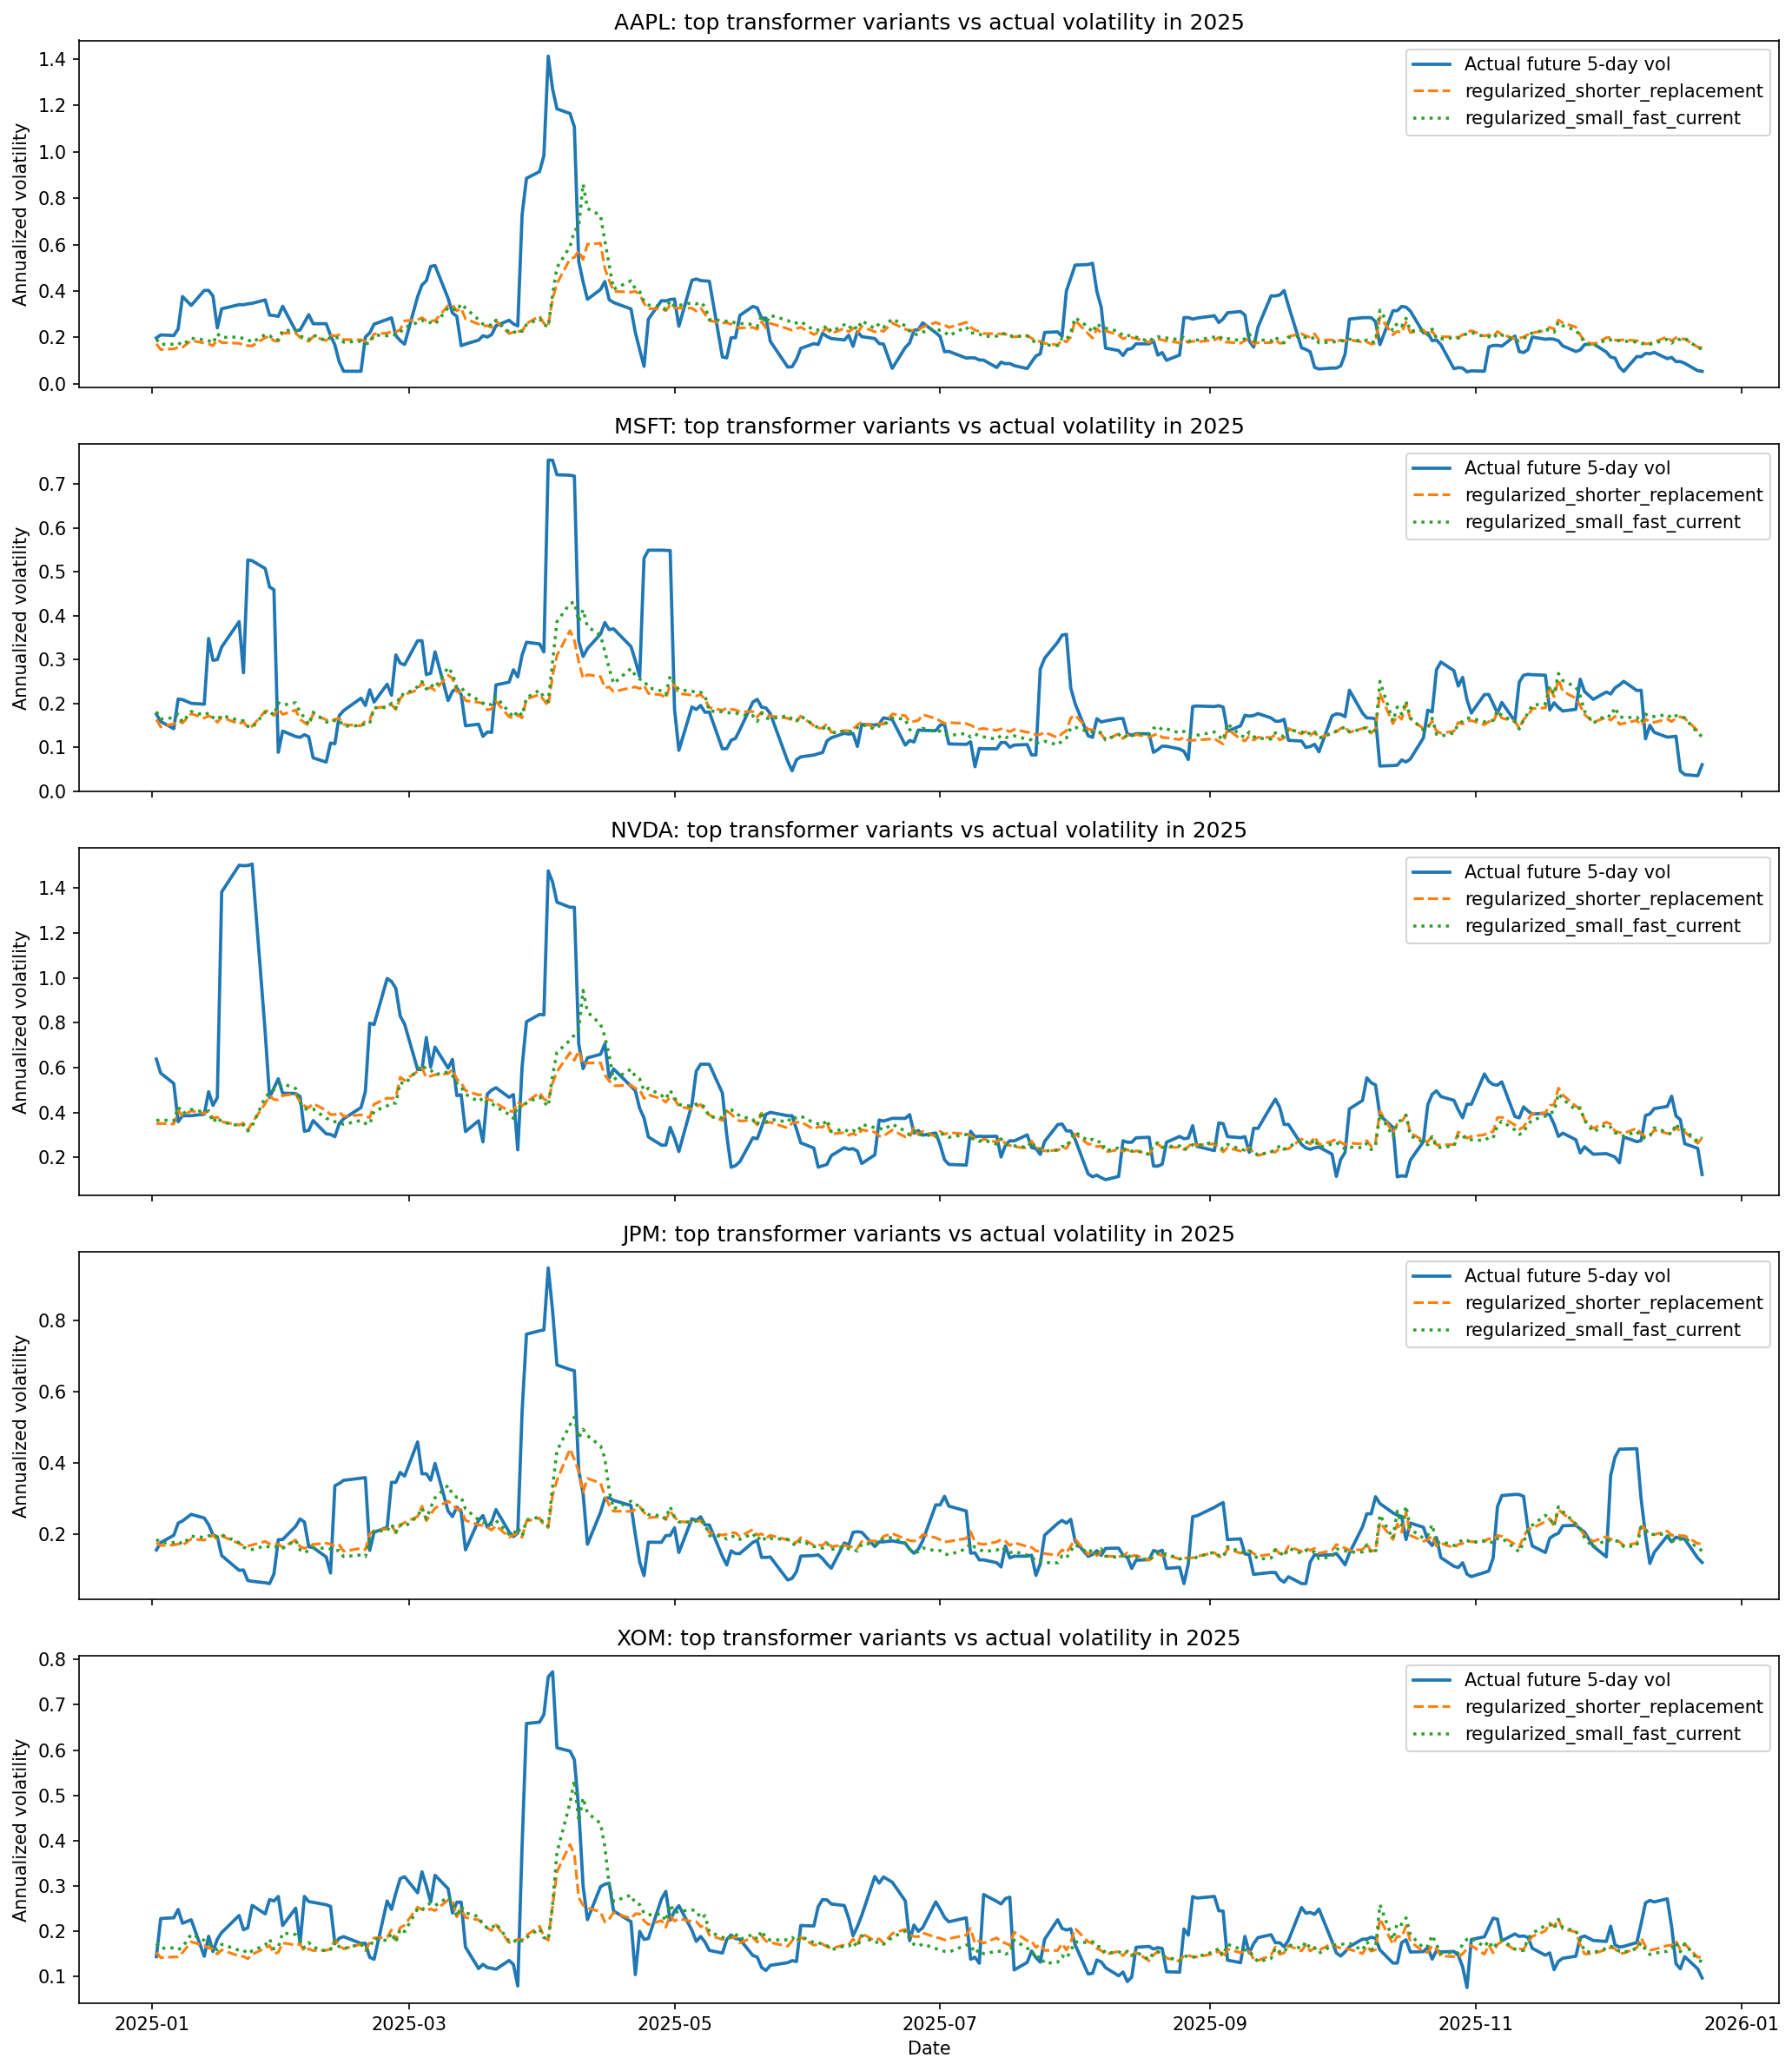

PosixPath('/Users/chonggu/Documents/Mine/Erdos 2026 Spring final project/figures/transformer_feature_replacement_5stocks.png')

In [8]:
top_two = experiment_summary_df['experiment'].head(2).tolist()
plot_df = test_prediction_map[top_two[0]].rename(columns={'prediction': top_two[0]})
plot_df = plot_df.merge(
    test_prediction_map[top_two[1]][['Date', 'Ticker', 'prediction']].rename(columns={'prediction': top_two[1]}),
    on=['Date', 'Ticker'],
    how='left',
)

fig, axes = plt.subplots(len(selected_tickers), 1, figsize=(14, 16), sharex=True)

for ax, ticker in zip(axes, selected_tickers):
    stock_plot_df = plot_df[plot_df['Ticker'] == ticker].sort_values('Date')
    ax.plot(stock_plot_df['Date'], stock_plot_df['fvol_5d'], label='Actual future 5-day vol', linewidth=1.8)
    ax.plot(stock_plot_df['Date'], stock_plot_df[top_two[0]], label=top_two[0], linestyle='--', linewidth=1.5)
    ax.plot(stock_plot_df['Date'], stock_plot_df[top_two[1]], label=top_two[1], linestyle=':', linewidth=1.7)
    ax.set_title(f'{ticker}: top transformer variants vs actual volatility in 2025')
    ax.set_ylabel('Annualized volatility')
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Date')
plt.tight_layout()

review_plot_path = FIGURE_DIR / 'transformer_feature_replacement_5stocks.png'
plt.savefig(review_plot_path, dpi=150, bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(review_plot_path)))

review_plot_path

## How to interpret the result

Use the output in this order:

- first compare `regularized_small_fast_current` to `regularized_small_replacement` to isolate the value of the feature replacement itself,
- then compare `regularized_small_replacement` to `regularized_shorter_replacement` to see whether a shorter lookback helps with lag,
- finally use the XGBoost importance table as support for which of the newly added features are plausibly doing the extra work.